## NumPy

The basics:

In [2]:
import numpy as np # standard import

data = np.array([[1.5, 0.1, 3], [0, -3, 6.5]])

data * 10 # scalar multiplication
data * data # element-wise multiplication

data + data # element-wise sum

data.shape

data.dtype # can be specified on initialization

np.zeros(10)
np.zeros((3, 6))
np.ones(3)
np.empty((2, 3, 2))
np.full((3, 3), 42) # filled with a specific value
np.arange(15)

np.zeros_like(data) # same shape of data - all other functions have the _like version too

np.eye(3) # or np.identity

data.astype(np.int64) # casting between data types - useful for converting from string to numbers too

data2 = np.array([[1, 2, 3], [4, 5, 6]])

data > data2 # returns a matrix with element-wise comparison

array([[ True, False, False],
       [False, False,  True]])

### Indexing:

In [3]:
arr = np.arange(10)

arr[5:8] = 12 # assigns to all elements in slice

arr

array([ 0,  1,  2,  3,  4, 12, 12, 12,  8,  9])

In [4]:
arr_slice = arr[1:3]

arr_slice[1] = 13 # will affect arr too. use copy() to avoid this

arr

array([ 0,  1, 13,  3,  4, 12, 12, 12,  8,  9])

In [5]:
arr_slice_copied = arr[1:3].copy()

arr_slice_copied[0] = 15 # won't affect original array
arr

array([ 0,  1, 13,  3,  4, 12, 12, 12,  8,  9])

In [6]:
arr_slice[:] = 14 # assign to the whole array
arr_slice

array([14, 14])

In [7]:
arr2d = np.array([[1, 2, 3],[4, 5, 6],[7, 8, 9]])

arr2d[1:, :2] # slicing in multiple dimensions
    

array([[4, 5],
       [7, 8]])

### Boolean indexing:

In [8]:
names = np.array(["Bob", "Joe", "Will", "Bob", "Will", "Joe", "Joe"])
data = np.array([[4, 7], [0, 2], [-5, 6], [0, 0], [1, 2], [-12, -4], [3, 4]])

names == "Bob"

array([ True, False, False,  True, False, False, False])

In [9]:
data[names == "Bob"]

array([[4, 7],
       [0, 0]])

In [10]:
# can be combined with other slicings:
data[names == "Bob", 1]

array([7, 0])

In [11]:
# can also be negated:
data[~(names == "Bob")] # or [names != "Bob"]

array([[  0,   2],
       [ -5,   6],
       [  1,   2],
       [-12,  -4],
       [  3,   4]])

In [12]:
# conditions can be combined:
mask = (names == "Bob") | (names == "Will") # for AND, use & - python's 'and' and 'or' don't work here
data[mask]

array([[ 4,  7],
       [-5,  6],
       [ 0,  0],
       [ 1,  2]])

**IMPORTANT:** Assigning the result of a boolean indexing to an array will _always_ create a copy of the data.

In [13]:
# setting all negative values to 0:
data[data < 0] = 0
data

array([[4, 7],
       [0, 2],
       [0, 6],
       [0, 0],
       [1, 2],
       [0, 0],
       [3, 4]])

### Fancy indexing:

In [14]:
arr = np.zeros((8, 4))
for i in range(8):
    arr[i] = i

arr

array([[0., 0., 0., 0.],
       [1., 1., 1., 1.],
       [2., 2., 2., 2.],
       [3., 3., 3., 3.],
       [4., 4., 4., 4.],
       [5., 5., 5., 5.],
       [6., 6., 6., 6.],
       [7., 7., 7., 7.]])

In [15]:
# select some of the rows in a specific order:
arr[[4, 3, 0, 6]]

array([[4., 4., 4., 4.],
       [3., 3., 3., 3.],
       [0., 0., 0., 0.],
       [6., 6., 6., 6.]])

In [16]:
arr = np.arange(32).reshape((8, 4))
arr

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23],
       [24, 25, 26, 27],
       [28, 29, 30, 31]])

In [17]:
# passing two arrays on indexing:
arr[[1, 5, 7, 2], [0, 3, 1, 2]] # the two arrays will be zipped together to form coordinates: (1, 0), (5, 3), ...

array([ 4, 23, 29, 10])

In [18]:
# to get a subset of rows and columns, do this:
arr[[1, 5, 7, 2]][:, [0, 3, 1, 2]]

array([[ 4,  7,  5,  6],
       [20, 23, 21, 22],
       [28, 31, 29, 30],
       [ 8, 11,  9, 10]])

### Transposing and swapping indexes

In [19]:
arr = np.arange(15).reshape((3, 5))

arr

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [20]:
arr.T # transposed - if we change this, original values will also be changed

array([[ 0,  5, 10],
       [ 1,  6, 11],
       [ 2,  7, 12],
       [ 3,  8, 13],
       [ 4,  9, 14]])

In [21]:
np.dot(arr.T, arr) # or arr @ arr.T

array([[125, 140, 155, 170, 185],
       [140, 158, 176, 194, 212],
       [155, 176, 197, 218, 239],
       [170, 194, 218, 242, 266],
       [185, 212, 239, 266, 293]])

In [22]:
# transpose is a specific case of swapping axes, where we swap 0 and 1:
arr.swapaxes(0, 1) # also doesn't return a copy

array([[ 0,  5, 10],
       [ 1,  6, 11],
       [ 2,  7, 12],
       [ 3,  8, 13],
       [ 4,  9, 14]])

### Pseudorandom generation

In [23]:
samples = np.random.standard_normal(size=(4, 4))
samples

array([[ 0.05912796,  1.01613761, -0.09080362, -1.68264448],
       [ 0.48771622, -0.36100946,  0.46926636,  1.03443596],
       [ 0.69056691,  2.077613  ,  0.85811572,  0.41237721],
       [-0.32437944,  3.09154276, -0.00983163,  0.68243565]])

In [24]:
rng = np.random.default_rng(seed=12345)
type(rng)

numpy.random._generator.Generator

There are many RNG methods in np: permutation, shuffle, uniform, etc.

### Universal functions (ufuncs): fast element-wise array functions

In [25]:
arr = np.arange(10)

np.exp(arr)
np.sqrt(arr) # these two are unary ufuncs

array([0.        , 1.        , 1.41421356, 1.73205081, 2.        ,
       2.23606798, 2.44948974, 2.64575131, 2.82842712, 3.        ])

In [26]:
x = rng.standard_normal(8)
y = rng.standard_normal(8)

np.maximum(x, y) # binary ufunc - takes the maximum value for each index in the two arrays

array([ 0.36105811,  1.26372846,  2.34740965,  0.96849691, -0.07534331,
        0.90219827, -0.46695317,  0.6488928 ])

### Array-oriented programming with arrays (vectorization)

In [27]:
points = np.arange(-5 ,5, 0.01)
xs, ys = np.meshgrid(points, points)

In [28]:
z = np.sqrt(xs ** 2 + ys ** 2)
z

array([[7.07106781, 7.06400028, 7.05693985, ..., 7.04988652, 7.05693985,
        7.06400028],
       [7.06400028, 7.05692568, 7.04985815, ..., 7.04279774, 7.04985815,
        7.05692568],
       [7.05693985, 7.04985815, 7.04278354, ..., 7.03571603, 7.04278354,
        7.04985815],
       ...,
       [7.04988652, 7.04279774, 7.03571603, ..., 7.0286414 , 7.03571603,
        7.04279774],
       [7.05693985, 7.04985815, 7.04278354, ..., 7.03571603, 7.04278354,
        7.04985815],
       [7.06400028, 7.05692568, 7.04985815, ..., 7.04279774, 7.04985815,
        7.05692568]], shape=(1000, 1000))

Text(0.5, 1.0, 'Image plot of $\\sqrt{x^2 + y^2}$ for a grid of values')

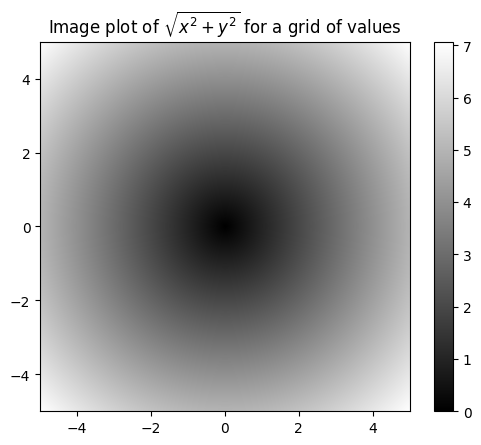

In [29]:
import matplotlib.pyplot as plt

plt.imshow(z, cmap=plt.cm.gray, extent=[-5, 5, -5, 5])
plt.colorbar()
plt.title("Image plot of $\sqrt{x^2 + y^2}$ for a grid of values")

#### Conditional logic as array operations

In [30]:
xarr = np.array([1.1, 1.2, 1.3, 1.4, 1.5])
yarr = np.array([2.1, 2.2, 2.3, 2.4, 2.5])
cond = np.array([True, False, True, True, False])

# ugly way:
# result = [(x if c else y) for x, y, c in zip(xarr, yarr, cond)]

result = np.where(cond, xarr, yarr)
result

array([1.1, 2.2, 1.3, 1.4, 2.5])

In [31]:
# can also be done with scalars:
arr = rng.standard_normal((4, 4))
np.where(arr > 0, 2, -2)

array([[ 2, -2,  2,  2],
       [ 2, -2,  2, -2],
       [-2,  2, -2, -2],
       [ 2,  2,  2,  2]])

#### Math and stats methods

In [ ]:
arr = rng.standard_normal((5, 4))

arr.mean() # same as np.mean(arr)
arr.sum()
arr.cumsum() # returns an array of intermediate results. axis argument changes the direction
arr.argmax() # index of biggest element

np.float64(-1.4060819569201075)

In [42]:
# specify an axis and get another dimension
arr = np.ones((3, 2))
arr[:, 1] = 2
arr.sum(axis=1)
arr

array([[1., 2.],
       [1., 2.],
       [1., 2.]])

#### Methods for boolean arrays

In [ ]:
arr = rng.standard_normal(100)

(arr > 0).sum() # counts positive values
(arr > 0).any() # returns True if there's any truthy value in the array. there's also all()

np.True_

#### Sorting

In [51]:
arr = rng.standard_normal((5, 3))

arr.sort(axis=1) # sort rows; 0 would sort columns
arr

array([[-1.48863945, -0.53979699,  0.07070287],
       [-1.50667492, -1.20842052, -1.13832102],
       [-0.30732952,  0.57623058,  1.74716204],
       [-0.38427167,  0.53491954,  0.86874368],
       [ 0.22245652,  0.54061588,  2.16953213]])

In [52]:
arr = rng.standard_normal((5, 3))
np.sort(arr) # returns a copy
arr # still not sorted

array([[ 0.2839281 , -0.22849051,  0.64616448],
       [ 1.77796354,  0.994308  , -0.47829989],
       [-0.85876457, -0.93085029, -0.66189936],
       [ 0.3865009 ,  0.84598829, -2.26994787],
       [-0.01866817, -1.10501888,  0.68289973]])

#### Unique and other set logic

In [54]:
names = np.array(["Bob", "Will", "Joe", "Bob", "Will", "Joe", "Joe"])
np.unique(names) # also sorts

array(['Bob', 'Joe', 'Will'], dtype='<U4')

In [58]:
values = np.array([6, 0, 0, 3, 2, 5, 6])

np.isin(values, [2, 3, 6]) # book presents in1d, but it's deprecated

np.union1d(values, np.array([1, 2, 3])) # there's also intersect, setdiff, setxor

array([0, 1, 2, 3, 5, 6])

### File I/O with arrays

In [61]:
arr = np.arange(10)

np.save("some_array", arr)

In [62]:
np.load("some_array.npy")

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [63]:
import os
os.remove("some_array.npy")

In [75]:
# save multiple arrays in a file, specifying keys:
np.savez("array_archive.npz", a=arr, b=arr) # there's also savez_compressed

In [ ]:
arch = np.load("array_archive.npz")
arch["a"]

In [76]:
import os
arch.close()
os.remove("array_archive.npz")

### Linear algebra

In [ ]:
x = np.array([[1., 2., 3.], [4., 5., 6.]])
y = np.array([[6., 23.], [-1., 7.], [8, 9]])

# these are all the same thing:
x.dot(y)
np.dot(x, y)
x @ y

array([[ 28.,  64.],
       [ 67., 181.]])

In [80]:
X = rng.standard_normal((5, 5))

X @ np.linalg.inv(X)

array([[ 1.00000000e+00, -3.69662652e-18,  5.29096394e-16,
        -8.82093854e-16,  9.78037073e-17],
       [ 1.39562274e-15,  1.00000000e+00, -5.56680040e-16,
         1.06954242e-15, -1.95154540e-16],
       [-4.62820549e-16,  4.75754775e-17,  1.00000000e+00,
        -1.48825382e-16,  1.01788529e-16],
       [ 7.56862212e-16, -1.04500761e-16, -5.25573913e-16,
         1.00000000e+00, -1.76744587e-16],
       [-1.34082638e-15,  1.01653570e-16,  2.98332983e-16,
        -1.78778027e-15,  1.00000000e+00]])

### Example: random walks

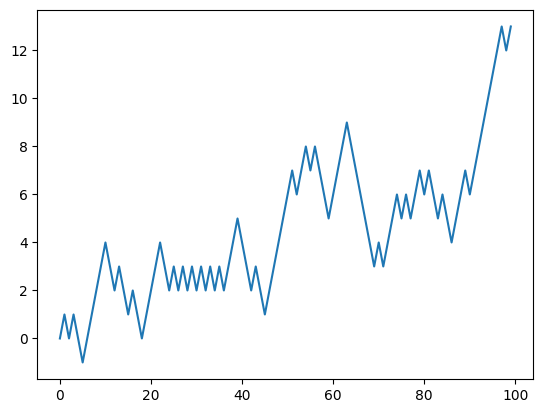

In [81]:
# in pure Python:
import random
position = 0
walk = [position]
nsteps = 1000
for _ in range(nsteps):
    step = 1 if random.randint(0, 1) else -1
    position += step
    walk.append(position)

plt.plot(walk[:100])

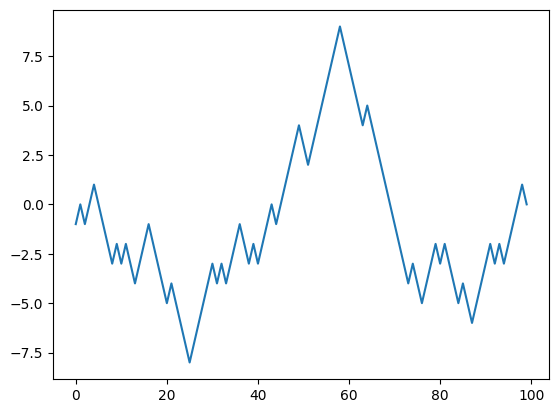

In [82]:
# with NumPy:
rng = np.random.default_rng(seed=12345)
draws = rng.integers(0, 2, size=nsteps)
steps = np.where(draws == 0, 1, -1)
walk = steps.cumsum()

plt.plot(walk[:100])

In [83]:
# first time the walk deviates 10 units from origin:
(np.abs(walk) >= 10).argmax()

np.int64(155)

In [85]:
# generating 5000 walks:
nwalks = 5000
nsteps = 1000

draws = rng.integers(0, 2, size=(nwalks, nsteps))
steps = np.where(draws == 0, 1, -1)
walks = steps.cumsum(axis=1) # sum across rows

walks.max()

np.int64(120)

In [91]:
# computing minimum crossing time of offset 30:
hits30 = (np.abs(walks) >= 30).any(axis=1)

hits30.sum() # number of walks that hit 30

crossing_times = (np.abs(walks[hits30]) >= 30).argmax(axis=1)
crossing_times.mean()

np.float64(500.69257950530033)